# E — Thermal Stress: Hours Above Temperature Thresholds
Counts how many hours per day each area spends above discomfort thresholds
(air temperature).  Uses standard thresholds:
- **28 °C** — warm discomfort onset
- **32 °C** — heat stress threshold
- **35 °C** — severe heat stress

**Saves to** `../figures/E_thermal_stress/`

In [1]:
import sys
from pathlib import Path
NB_DIR = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
sys.path.insert(0, str(NB_DIR))
from config import *
import matplotlib.patches as mpatches

SAVE_DIR = FIGURES_DIR / 'E_thermal_stress'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLDS = [28, 32, 35]          # °C
THRESH_COLORS = ['#F4D03F', '#E67E22', '#C0392B']
THRESH_LABELS = ['≥28 °C (warm)', '≥32 °C (heat stress)', '≥35 °C (severe)']

print('Setup done. Saving to:', SAVE_DIR)

Config loaded.  ROOT=/home/mourouzidou/Downloads/Anastasia
Output dir : /home/mourouzidou/Downloads/Anastasia/output
Figures dir: /home/mourouzidou/Downloads/Anastasia/figures
Setup done. Saving to: /home/mourouzidou/Downloads/Anastasia/figures/E_thermal_stress


In [2]:
print('Loading atmosphere...'); atm_raw = load_csvs('atmosphere')
atm = atm_raw[atm_raw[BUILDING_COL] == 0].copy() if BUILDING_COL in atm_raw.columns else atm_raw.copy()
print(f'Outdoor atmosphere rows: {len(atm):,}')

Loading atmosphere...
  Shaded_15Aug_atmosphere.parquet  →  260,000 rows
  Shaded_15Feb_atmosphere.parquet  →  260,000 rows
  Shaded_15Nov_atmosphere.parquet  →  510,000 rows
  Shaded_31Mar_atmosphere.parquet  →  260,000 rows
  Waterfront_15Aug_atmosphere.parquet  →  260,000 rows
  Waterfront_15Feb_atmosphere.parquet  →  260,000 rows
  Waterfront_15Nov_atmosphere.parquet  →  260,000 rows
  Waterfront_31Mar_atmosphere.parquet  →  260,000 rows
  Zefkseidos_15Aug_atmosphere.parquet  →  300,000 rows
  Zefkseidos_15Feb_atmosphere.parquet  →  260,000 rows
  Zefkseidos_15Nov_atmosphere.parquet  →  260,000 rows
  Zefkseidos_31Mar_atmosphere.parquet  →  260,000 rows
Outdoor atmosphere rows: 3,337,982


## E1 — Hours above threshold: grouped bar chart (area × date)

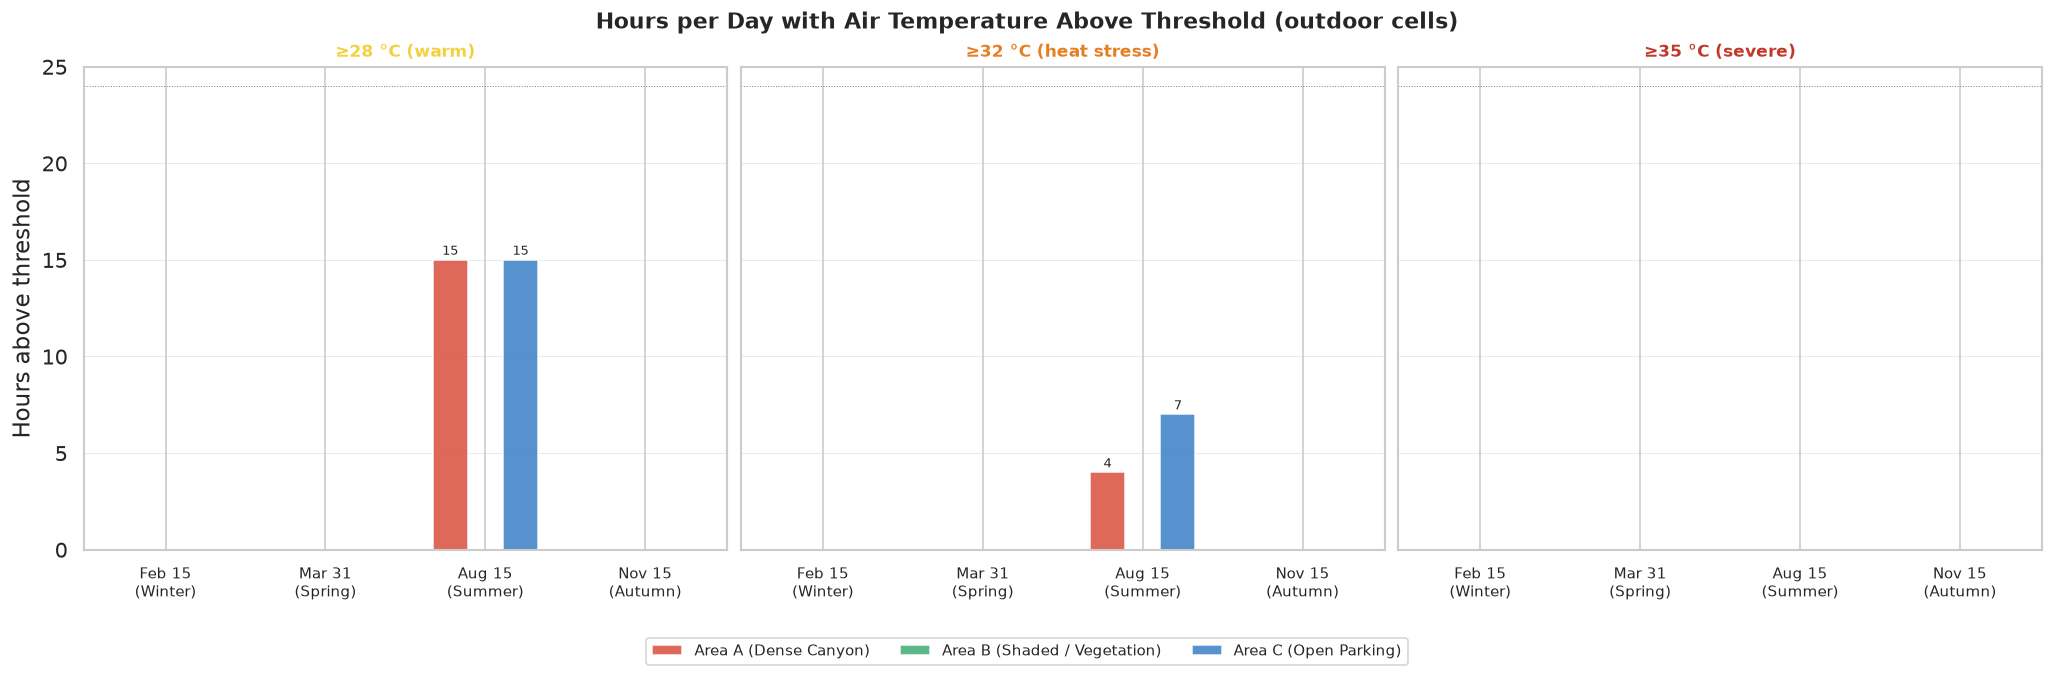

Saved E1


In [3]:
def hours_above(df, col, threshold):
    """For each (area, date), count mean hours where median hourly temp > threshold."""
    rows = []
    for area in AREA_ORDER:
        for date in DATE_ORDER:
            sub = df[(df['area'] == area) & (df['date'] == date)]
            if len(sub) == 0:
                rows.append({'area': area, 'date': date, 'hours': 0})
                continue
            # hourly median across all grid cells
            h_med = sub.groupby('hour')[col].median()
            rows.append({'area': area, 'date': date, 'hours': int((h_med > threshold).sum())})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, len(THRESHOLDS), figsize=(17, 5), sharey=True, constrained_layout=True)
fig.suptitle('Hours per Day with Air Temperature Above Threshold (outdoor cells)',
             fontsize=13, fontweight='bold')

x_pos = np.arange(len(DATE_ORDER))
width = 0.22

for ax, thresh, tc, tl in zip(axes, THRESHOLDS, THRESH_COLORS, THRESH_LABELS):
    ax.set_title(tl, fontsize=10, fontweight='bold', color=tc)
    ax.set_ylabel('Hours above threshold') if thresh == THRESHOLDS[0] else None
    ha_df = hours_above(atm, AIR_TEMP_COL, thresh)

    for i, area in enumerate(AREA_ORDER):
        vals = [ha_df[(ha_df['area'] == area) & (ha_df['date'] == d)]['hours'].values[0]
                for d in DATE_ORDER]
        offset = (i - 1) * width
        bars = ax.bar(x_pos + offset, vals, width, color=AREA_COLORS[area], alpha=0.85,
                      label=AREA_LABELS[area].replace('\n', ' '))
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                        str(v), ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([DATE_LABELS[d].replace(' (', '\n(') for d in DATE_ORDER], fontsize=9)
    ax.set_ylim(0, 25)
    ax.axhline(24, color='grey', lw=0.6, ls=':')
    ax.grid(axis='y', lw=0.5, alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), frameon=True)
fig.savefig(SAVE_DIR / 'E1_hours_above_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved E1')

## E2 — Heatmap: threshold hours by area × date

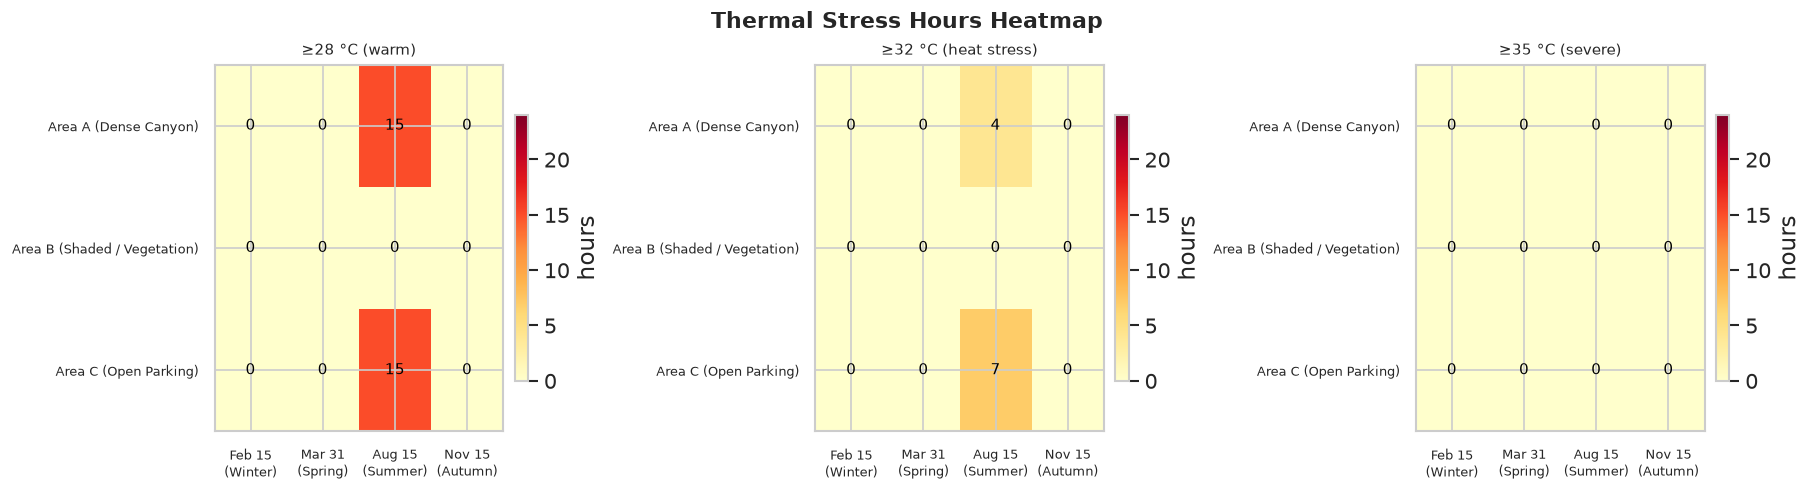

Saved E2


In [4]:
fig, axes = plt.subplots(1, len(THRESHOLDS), figsize=(15, 4), constrained_layout=True)
fig.suptitle('Thermal Stress Hours Heatmap', fontsize=13, fontweight='bold')

for ax, thresh, tl in zip(axes, THRESHOLDS, THRESH_LABELS):
    ha_df = hours_above(atm, AIR_TEMP_COL, thresh)
    mat = ha_df.pivot(index='area', columns='date', values='hours')
    mat = mat.reindex(index=AREA_ORDER, columns=DATE_ORDER)

    im = ax.imshow(mat.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=24)
    ax.set_title(tl, fontsize=9)
    ax.set_xticks(range(len(DATE_ORDER)))
    ax.set_xticklabels([DATE_LABELS[d].replace(' (', '\n(') for d in DATE_ORDER], fontsize=8)
    ax.set_yticks(range(len(AREA_ORDER)))
    ax.set_yticklabels([AREA_LABELS[a].replace('\n', ' ') for a in AREA_ORDER], fontsize=8)

    for i in range(len(AREA_ORDER)):
        for j in range(len(DATE_ORDER)):
            v = mat.values[i, j]
            ax.text(j, i, str(int(v)) if not np.isnan(v) else '?',
                    ha='center', va='center', fontsize=9,
                    color='white' if v > 16 else 'black')

    plt.colorbar(im, ax=ax, label='hours', fraction=0.046, pad=0.04)

fig.savefig(SAVE_DIR / 'E2_thermal_stress_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved E2')

## E3 — Temperature exceedance curve (CDF complement) for summer

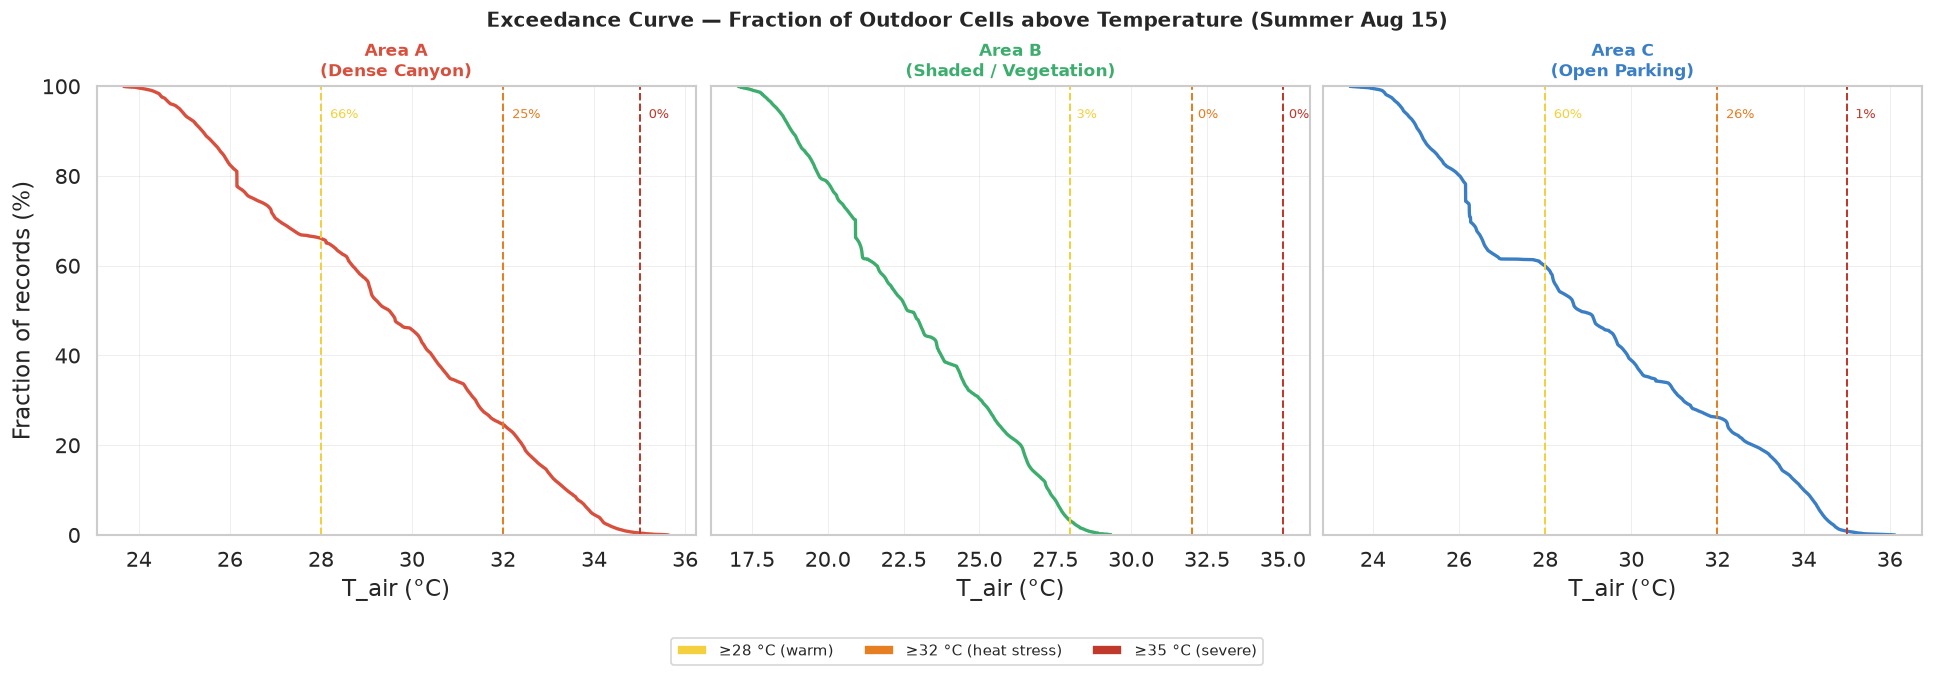

Saved E3


In [5]:
fig, axes = plt.subplots(1, len(AREA_ORDER), figsize=(16, 5), sharey=True, constrained_layout=True)
fig.suptitle('Exceedance Curve — Fraction of Outdoor Cells above Temperature (Summer Aug 15)',
             fontsize=12, fontweight='bold')

for ax, area in zip(axes, AREA_ORDER):
    ax.set_title(AREA_LABELS[area], fontsize=10, fontweight='bold', color=AREA_COLORS[area])
    ax.set_xlabel('T_air (°C)')
    if area == AREA_ORDER[0]: ax.set_ylabel('Fraction of records (%)')

    sub_all = atm[(atm['area'] == area) & (atm['date'] == '15Aug')][AIR_TEMP_COL].dropna()
    if len(sub_all) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    vals = np.sort(sub_all.values)
    pct  = (1 - np.arange(1, len(vals) + 1) / len(vals)) * 100
    ax.plot(vals, pct, color=AREA_COLORS[area], lw=2)

    for thresh, tc, tl in zip(THRESHOLDS, THRESH_COLORS, THRESH_LABELS):
        frac = (sub_all > thresh).mean() * 100
        ax.axvline(thresh, color=tc, lw=1.2, ls='--')
        ax.text(thresh + 0.2, 95, f'{frac:.0f}%', fontsize=7.5, color=tc, va='top')

    ax.set_ylim(0, 100)
    ax.grid(lw=0.4, alpha=0.5)

thresh_patches = [mpatches.Patch(facecolor=tc, label=tl)
                  for tc, tl in zip(THRESH_COLORS, THRESH_LABELS)]
fig.legend(handles=thresh_patches, loc='upper center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), frameon=True)
fig.savefig(SAVE_DIR / 'E3_exceedance_curve_summer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved E3')

## E4 — Summary table: hours above each threshold

In [6]:
rows = []
for area in AREA_ORDER:
    for date in DATE_ORDER:
        sub = atm[(atm['area'] == area) & (atm['date'] == date)]
        if len(sub) == 0: continue
        h_med = sub.groupby('hour')[AIR_TEMP_COL].median()
        row = {'Area': area, 'Date': date}
        for thresh in THRESHOLDS:
            row[f'h≥{thresh}°C'] = int((h_med > thresh).sum())
        rows.append(row)
stress_df = pd.DataFrame(rows)
print(stress_df.to_string(index=False))
print('\nAll done. Figures saved to:', SAVE_DIR)

      Area  Date  h≥28°C  h≥32°C  h≥35°C
Zefkseidos 15Feb       0       0       0
Zefkseidos 31Mar       0       0       0
Zefkseidos 15Aug      15       4       0
Zefkseidos 15Nov       0       0       0
    Shaded 15Feb       0       0       0
    Shaded 31Mar       0       0       0
    Shaded 15Aug       0       0       0
    Shaded 15Nov       0       0       0
Waterfront 15Feb       0       0       0
Waterfront 31Mar       0       0       0
Waterfront 15Aug      15       7       0
Waterfront 15Nov       0       0       0

All done. Figures saved to: /home/mourouzidou/Downloads/Anastasia/figures/E_thermal_stress
